## Noise covariance mismatch: binned errorbar disagreement

Same as `noise_mismatch_demo.ipynb` but with a **small mask** where $F_\ell$ is
rank-deficient, requiring posthoc binning. The mismatch between band-limited
`synalm(C_{aa})` noise and the fiducial's white pixel noise $N_a/\omega\cdot I$
shows up as a systematic deviation of the empirical binned errorbars from $F_b^{-1}$.

Two sim modes, side by side:
1. **Mismatched:** `synalm(C_{aa})` — band-limited noise $\neq$ fiducial
2. **Matched:** `synalm(S_{aa})` + pixel white noise — $C_{\rm true} = C_{\rm fid}$

Both use noise-bias subtraction. Only the errorbars differ.

In [1]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
from tqdm import tqdm

from utilities import *
from qmlfast import *

### Setup

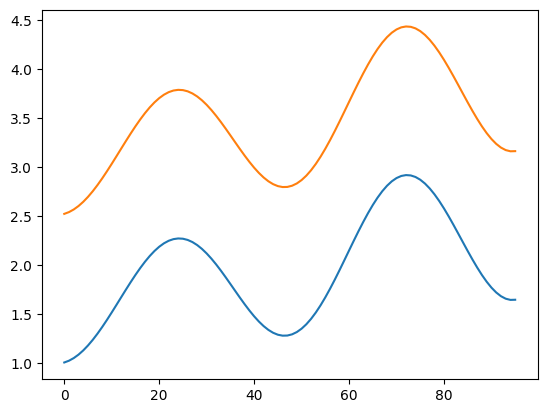

In [2]:
nside = 32
lmax = 3 * nside - 1
n_ell = 3 * nside
ell = np.arange(n_ell, dtype=float)

S_aa = np.exp((ell+1)/n_ell/2) * (1 + np.sin((ell+1)/n_ell*np.pi*2)**2)
N_a = 1.5*S_aa[0]
C_aa = S_aa + N_a


Nf = 1
plt.plot(ell, S_aa)
plt.plot(ell, C_aa)

### Mask (small sky fraction)

Mask small enough that $F_\ell$ is rank-deficient and per-$\ell$
inversion fails, making binning necessary.

/home/ykvasiuk/miniconda3/envs/pyccl/lib/python3.11/site-packages/healpy/pixelfunc.py:1507: RuntimeWarning: invalid value encountered in _get_neigbors_ring
  r = pixlib._get_neighbors_ring(nside, theta)


Sky fraction: 0.12
Np = 1521


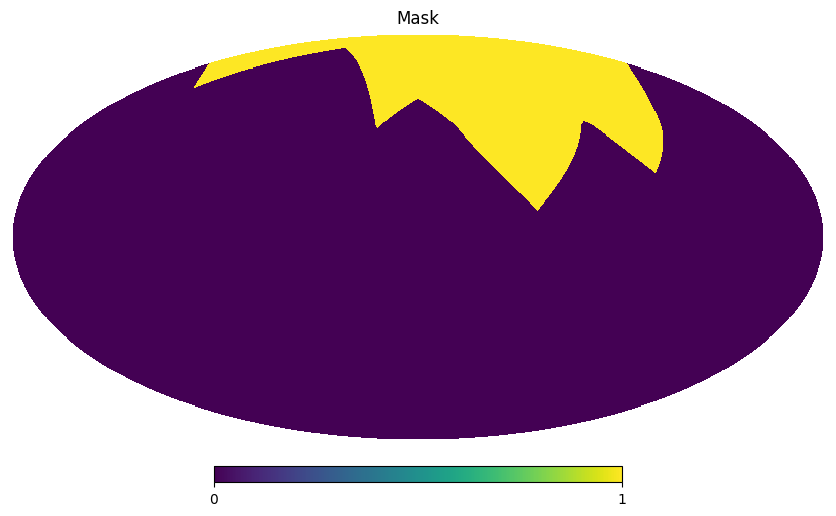

In [3]:
def gen_mask_patch(nside, seed, niter):
    npix = hp.nside2npix(nside)
    idx_bound = seed
    mask = np.zeros(npix)
    mask[seed] = 1
    masks = np.zeros((niter, npix))
    for i in range(niter):
        mask_idx = np.arange(npix)[mask != 0]
        idx = np.unique(hp.get_all_neighbours(nside, idx_bound).flatten())
        mask[idx] = 1
        masks[i] = mask
        idx_bound = np.unique(idx[~np.isin(idx, mask_idx)])
    return masks

masks = gen_mask_patch(nside, 600, 30)
mask = masks[18]
#hp.mollview(mask)
hp.mollview(mask, title='Mask')
print(f'Sky fraction: {mask.mean():.2f}')

theta, phi = theta_phi(nside)
theta = theta[mask == 1]
phi = phi[mask == 1]
Np = int(mask.sum())
omega_pix = 4 * np.pi / hp.nside2npix(nside)
print(f'Np = {Np}')

### Pixel covariance (signal + white pixel noise)

In [4]:
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

N_pix_diag = N_a / omega_pix
large_cov = get_pix_cov_block(S_aa, Pl_ij, 0, lmax + 1) + np.eye(Np) * N_pix_diag

print(f'cond(C_fid) = {np.linalg.cond(large_cov):.2e}')
Cinv = np.linalg.inv(large_cov)
C_map = np.ones((Nf, Nf))

Pl_ij: 100%|█████████████████████████████████████████████████████████| 96/96 [00:01<00:00, 75.77it/s]


cond(C_fid) = 4.14e+00


### Binning matrix

In [5]:
bin_edges = []
l = 0
delta_ell = 3
while l < n_ell:
    bin_edges.append((l, min(l + delta_ell, n_ell)))
    l += delta_ell

n_bins = len(bin_edges)
P = np.zeros((n_bins, n_ell))
for b, (lo, hi) in enumerate(bin_edges):
    P[b, lo:hi] = 1.0 / (hi - lo)

S_unbin = P.T @ np.linalg.inv(P @ P.T)
ell_eff = np.array([(lo + hi - 1) / 2 for lo, hi in bin_edges])
n_pairs = 1

print(f'Number of bins: {n_bins}')
for b, (lo, hi) in enumerate(bin_edges):
    print(f'  bin {b:2d}: ell = {lo}..{hi-1} (width {hi-lo})')

Number of bins: 32
  bin  0: ell = 0..2 (width 3)
  bin  1: ell = 3..5 (width 3)
  bin  2: ell = 6..8 (width 3)
  bin  3: ell = 9..11 (width 3)
  bin  4: ell = 12..14 (width 3)
  bin  5: ell = 15..17 (width 3)
  bin  6: ell = 18..20 (width 3)
  bin  7: ell = 21..23 (width 3)
  bin  8: ell = 24..26 (width 3)
  bin  9: ell = 27..29 (width 3)
  bin 10: ell = 30..32 (width 3)
  bin 11: ell = 33..35 (width 3)
  bin 12: ell = 36..38 (width 3)
  bin 13: ell = 39..41 (width 3)
  bin 14: ell = 42..44 (width 3)
  bin 15: ell = 45..47 (width 3)
  bin 16: ell = 48..50 (width 3)
  bin 17: ell = 51..53 (width 3)
  bin 18: ell = 54..56 (width 3)
  bin 19: ell = 57..59 (width 3)
  bin 20: ell = 60..62 (width 3)
  bin 21: ell = 63..65 (width 3)
  bin 22: ell = 66..68 (width 3)
  bin 23: ell = 69..71 (width 3)
  bin 24: ell = 72..74 (width 3)
  bin 25: ell = 75..77 (width 3)
  bin 26: ell = 78..80 (width 3)
  bin 27: ell = 81..83 (width 3)
  bin 28: ell = 84..86 (width 3)
  bin 29: ell = 87..89 (width 3

### Per-$\ell$ Fisher and binned Fisher

In [6]:
Y_r_all = sph_harm_y_real_all(n_ell, theta, phi)
F_idx = np.array([(0, 0, l) for l in range(n_ell)])
V_packed, offsets, ranks = pack_sph_harm(Y_r_all)
F_ell = getF_packed(V_packed, offsets, ranks, Cinv, F_idx, Nf, Np, C_map)

print(f'F_ell shape: {F_ell.shape}, rank: {np.linalg.matrix_rank(F_ell)}')

block_P = np.kron(P, np.eye(n_pairs))
block_S = np.kron(S_unbin, np.eye(n_pairs))

F_b = block_S.T @ F_ell @ block_S
inv_Fb = np.linalg.inv(F_b)

PFS = block_P @ F_ell @ block_S
M_posthoc = np.linalg.inv(PFS) @ block_P

print(f'F_b shape: {F_b.shape}, rank: {np.linalg.matrix_rank(F_b)}')

VCinvV: 100%|██████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.30s/it]


F_ell shape: (96, 96), rank: 65
F_b shape: (32, 32), rank: 32


### Noise bias

$b_\ell = \tfrac12(N_a/\omega)\,\mathrm{Tr}(C^{-2} P_\ell)$

In [7]:
noise_bias = get_noise_bias_packed_white(
    V_packed, offsets, ranks, Cinv, F_idx, Nf, Np,
    np.array([N_pix_diag]))


noise bias: 100%|██████████████████████████████████████████████████| 96/96 [00:00<00:00, 7679.09it/s]


### Run simulations: mismatched vs matched

Both use noise-bias subtraction and posthoc binning.

In [8]:
n_sims = 2500
rng = np.random.default_rng(42)

ys_mismatch = []
ys_match = []

for i in tqdm(range(n_sims)):
    # ── Mismatched: synalm(C_aa) — band-limited noise ──
    alm_total = hp.synalm(C_aa, lmax=lmax)
    x_mis = np.array([hp.alm2map(alm_total, nside)[mask == 1]])
    y_mis = get_y_packed(x_mis, V_packed, offsets, ranks, Cinv, F_idx, Nf, Np)
    ys_mismatch.append(y_mis - noise_bias)

    # ── Matched: synalm(S_aa) + pixel noise ──
    alm_sig = hp.synalm(S_aa, lmax=lmax)
    sig = hp.alm2map(alm_sig, nside)[mask == 1]
    noise = rng.normal(0, np.sqrt(N_pix_diag), Np)
    x_mat = np.array([sig + noise])
    y_mat = get_y_packed(x_mat, V_packed, offsets, ranks, Cinv, F_idx, Nf, Np)
    ys_match.append(y_mat - noise_bias)

ys_mismatch = np.array(ys_mismatch)
ys_match = np.array(ys_match)
print(f'shapes: {ys_mismatch.shape}, {ys_match.shape}')

100%|████████████████████████████████████████████████████████████| 2500/2500 [11:32<00:00,  3.61it/s]

shapes: (2500, 96), (2500, 96)


### Posthoc binning

### Appendix A: true analytic covariance of the mismatched estimator

When $C_{\rm fid} \neq C_{\rm true}$, $\mathrm{Cov}(\hat y) = G \neq \tilde F$,
where:

$$G_{\ell\ell'} = \tfrac12\,\mathrm{Tr}\!\left(
C_{\rm fid}^{-1} P_\ell\, C_{\rm fid}^{-1} C_{\rm true}\,
C_{\rm fid}^{-1} P_{\ell'}\, C_{\rm fid}^{-1} C_{\rm true}\right)$$

So the actual covariance of $\hat c = \tilde F^{-1}\hat y$ is
$\tilde F^{-1} G \tilde F^{-1}$, not $\tilde F^{-1}$.

We compute $G$ using the low-rank decomposition $P_\ell = V_\ell^T V_\ell$
to avoid storing full $N_p \times N_p$ matrices per $\ell$.

In [9]:
# True pixel covariance of mismatched sims: band-limited C_aa
C_true_mis = get_pix_cov_block(C_aa, Pl_ij, 0, lmax + 1)
W_mis = Cinv @ C_true_mis  # "whitened" true cov

# Precompute low-rank factors: u_l = Cinv V_l^T, v_l = V_l W_mis
u_list = []
v_list = []
for l in range(n_ell):
    r = 2*l + 1
    V_l = Y_r_all[l, :r, :]
    u_list.append(Cinv @ V_l.T)   # (Np, r_l)
    v_list.append(V_l @ W_mis)    # (r_l, Np)

# G_ll' = 0.5 * Tr(A_l A_l') where A_l = u_l @ v_l
# Using cyclic trace: Tr(u v u' v') = Tr((v u')(v' u)) = sum(K1 * K2.T)
G = np.zeros((n_ell, n_ell))
for l1 in tqdm(range(n_ell), desc='G matrix'):
    for l2 in range(l1 + 1):
        K1 = v_list[l1] @ u_list[l2]   # (r_l1, r_l2)
        K2 = v_list[l2] @ u_list[l1]   # (r_l2, r_l1)
        G[l1, l2] = 0.5 * np.sum(K1 * K2.T)
        G[l2, l1] = G[l1, l2]

print(f'G shape: {G.shape}')
print(f'||G - F||/||F|| = {np.linalg.norm(G - F_ell)/np.linalg.norm(F_ell):.3e}  '
      f'(should be > 0 for mismatch)')

G matrix: 100%|██████████████████████████████████████████████████████| 96/96 [00:03<00:00, 29.47it/s]

G shape: (96, 96)
||G - F||/||F|| = 1.149e-01  (should be > 0 for mismatch)


In [10]:
c_mis = ys_mismatch @ M_posthoc.T
c_mat = ys_match @ M_posthoc.T

c_mean_mis = c_mis.mean(axis=0)
c_mean_mat = c_mat.mean(axis=0)
c_cov_mis = np.cov(c_mis, rowvar=False, ddof=1)
c_cov_mat = np.cov(c_mat, rowvar=False, ddof=1)

sigma_mis = np.sqrt(np.diag(c_cov_mis))
sigma_mat = np.sqrt(np.diag(c_cov_mat))
sigma_an  = np.sqrt(np.diag(inv_Fb))  # naive: assumes Cov(y) = F

# Appendix A: true analytic cov when fid != true
# Cov(c_b) = M G M^T, not inv_Fb
cov_appA_b = M_posthoc @ G @ M_posthoc.T
sigma_appA = np.sqrt(np.diag(cov_appA_b))

# Fisher-weighted truth (signal only)
S_true_b = inv_Fb @ (block_S.T @ F_ell @ S_aa[:n_ell])


### Errorbar ratio: $\sigma_{\rm emp} / \sqrt{\mathrm{diag}\,F_b^{-1}}$

Mismatched should deviate (especially the last bin near $\ell_{\max}$);
matched should scatter around 1.

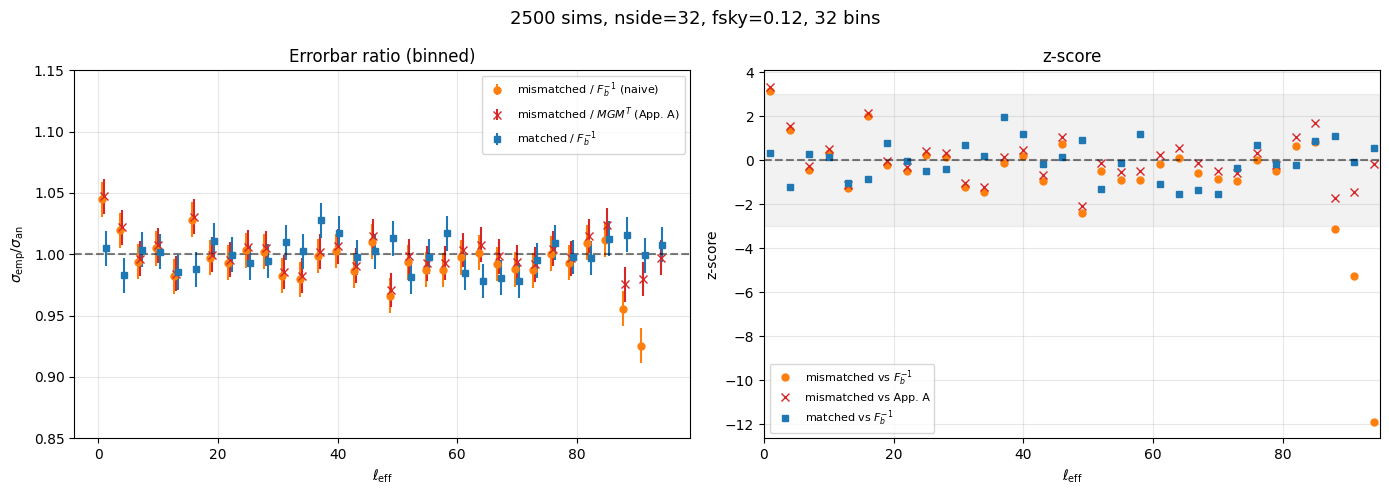

In [11]:
ratio_err = 1.0 / np.sqrt(2 * (n_sims - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
dx = 0.3
ax.errorbar(ell_eff - dx, sigma_mis / sigma_an, yerr=ratio_err, fmt='o', ms=5,
            color='C1', label='mismatched / $F_b^{-1}$ (naive)')
ax.errorbar(ell_eff, sigma_mis / sigma_appA, yerr=ratio_err, fmt='x', ms=6,
            color='C3', label=r'mismatched / $MGM^T$ (App. A)')
ax.errorbar(ell_eff + dx, sigma_mat / sigma_an, yerr=ratio_err, fmt='s', ms=5,
            color='C0', label='matched / $F_b^{-1}$')
ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\sigma_{\rm emp} / \sigma_{\rm an}$')
ax.set_title('Errorbar ratio (binned)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(0.85, 1.15)

ax = axes[1]
z_mis_naive = (sigma_mis / sigma_an - 1) / ratio_err
z_mis_appA  = (sigma_mis / sigma_appA - 1) / ratio_err
z_mat       = (sigma_mat / sigma_an - 1) / ratio_err
ax.plot(ell_eff, z_mis_naive, 'o', ms=5, color='C1',
        label='mismatched vs $F_b^{-1}$')
ax.plot(ell_eff, z_mis_appA, 'x', ms=6, color='C3',
        label=r'mismatched vs App. A')
ax.plot(ell_eff, z_mat, 's', ms=5, color='C0',
        label='matched vs $F_b^{-1}$')
ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.fill_between([ell_eff[0]-1, ell_eff[-1]+1], -3, 3,
                alpha=0.1, color='gray')
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel('z-score')
ax.set_title('z-score')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(ell_eff[0]-1, ell_eff[-1]+1)

plt.suptitle(f'{n_sims} sims, nside={nside}, fsky={mask.mean():.2f}, {n_bins} bins',
             fontsize=13)
plt.tight_layout()
plt.show()


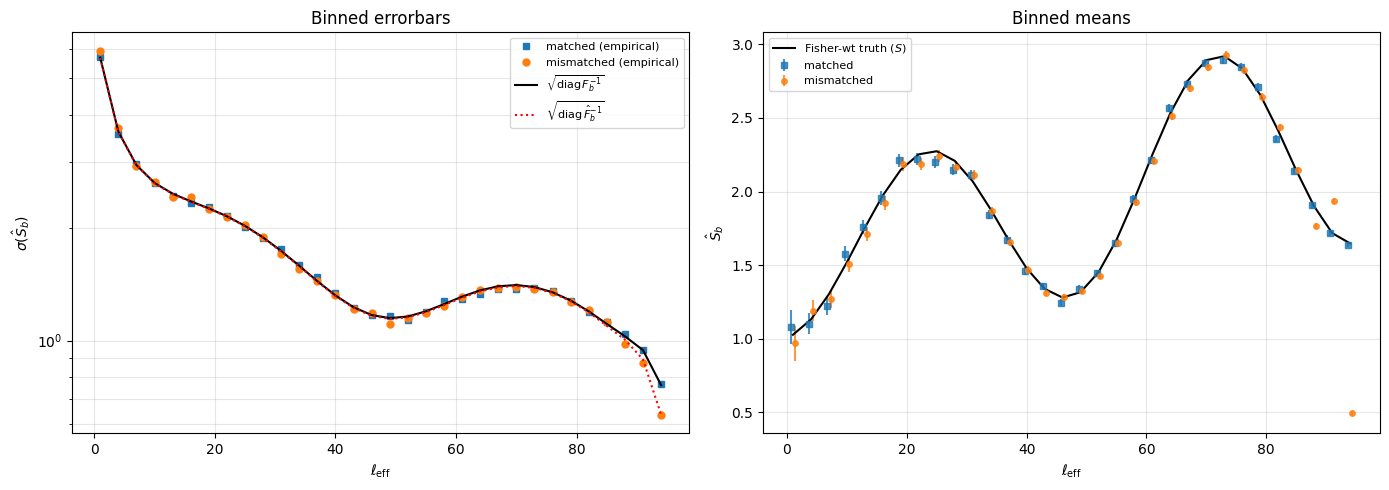

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(ell_eff, sigma_mat, 's', ms=5, color='C0', label='matched (empirical)')
ax.semilogy(ell_eff, sigma_mis, 'o', ms=5, color='C1', label='mismatched (empirical)')
ax.semilogy(ell_eff, sigma_an, 'k-', lw=1.5, label=r'$\sqrt{\mathrm{diag}\,F_b^{-1}}$')
ax.semilogy(ell_eff, sigma_appA, 'r:', lw=1.5, label=r'$\sqrt{\mathrm{diag}\,\hat{F}_b^{-1}}$')

ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\sigma(\hat S_b)$')
ax.set_title('Binned errorbars')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

ax = axes[1]
dx = 0.3
ax.errorbar(ell_eff - dx, c_mean_mat, yerr=sigma_mat/np.sqrt(n_sims), fmt='s', ms=4,
            color='C0', label='matched', alpha=0.8)
ax.errorbar(ell_eff + dx, c_mean_mis, yerr=sigma_mis/np.sqrt(n_sims), fmt='o', ms=4,
            color='C1', label='mismatched', alpha=0.8)
ax.plot(ell_eff, S_true_b, 'k-', lw=1.5, label='Fisher-wt truth ($S$)')
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\hat S_b$')
ax.set_title('Binned means')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Summary

In [13]:
ratio_mis = sigma_mis / sigma_an
ratio_mat = sigma_mat / sigma_an
ratio_mis_1 = sigma_mis / sigma_appA
print(f'Matched    — mean ratio: {ratio_mat.mean():.4f}, '
      f'std: {ratio_mat.std():.4f}, ')
print(f'Mismatched — mean ratio: {ratio_mis.mean():.4f}, '
      f'std: {ratio_mis.std():.4f}, ')

print(f'Mismatched vs. mismatch — mean ratio: {ratio_mis_1.mean():.4f}, '
      f'std: {ratio_mis_1.std():.4f}, ')


Matched    — mean ratio: 0.9997, std: 0.0125, 
Mismatched — mean ratio: 0.9893, std: 0.0349, 
Mismatched vs. mismatch — mean ratio: 1.0006, std: 0.0157, 
